# Introduction to Python for Quantum Computing

**Quantum Computing Spring School 2026**
Session 1 · Python for Quantum Computing · ~90 minutes

Welcome! This notebook is a general, hands-on introduction to Python and its core scientific libraries. No prior programming experience is assumed.

**What we'll cover today:**

1. Why Python, and how Jupyter notebooks work
2. Python fundamentals — variables, types, operators, control flow
3. Data structures — lists, tuples, dictionaries, sets
4. Functions and a first look at classes/objects
5. Packages and environments — Anaconda, `conda`, `pip`
6. Scientific Python — NumPy, SciPy, Matplotlib

This session is deliberately **general-purpose Python** — it does not touch quantum computing concepts, qubits, or Qiskit. That's the focus of a later session, once you have the Python fluency to focus entirely on the quantum ideas rather than fighting the language at the same time.

Each section has one or more **Exercises** — do these yourself before looking at the solution cell underneath.

---

## 1. Why Python, and how this notebook works

Python is one of the most widely used programming languages in research and scientific computing — it's readable, has a huge ecosystem of libraries (including NumPy, SciPy, and Matplotlib, which we'll use today), and doesn't require you to manage memory or compile anything: you write code and run it immediately. You'll keep building on today's skills throughout the rest of the school.

This document is a **Jupyter notebook**. It's made of *cells*:

- **Markdown cells** (like this one) hold formatted text, explanations, and headings.
- **Code cells** hold Python code you can run.

To run a code cell in Jupyter: click it and press **Shift+Enter** (runs it, moves to the next cell) or **Ctrl+Enter** (runs it, stays put). Try it on the cell below.

In [1]:
print("Hello, Spring School!")

Hello, Spring School!


A few notebook habits worth knowing immediately:

- Cells share state — a variable defined in one cell is available in later cells, in the order you *ran* them (not necessarily the order they appear on the page). Restart-and-run-all before you trust a notebook end to end.
- The output of the **last line** of a cell is displayed automatically, without needing `print`:

In [2]:
3 + 4  # this shows "7" as output, even without print()

7

- `print()` is still needed if you want to show something that *isn't* the last line, or want multiple outputs from one cell.

In [3]:
print("first line")
print("second line")
5 * 5  # only this last expression's value is auto-displayed, after both prints

first line
second line


25

---

## 2. Python fundamentals

### 2.1 Variables and assignment

A variable is a name pointing at a value. Python figures out the type for you — you don't declare it up front (this is called *dynamic typing*).

In [4]:
book_title = "Dune"
price = 24.99
in_stock = True

print(book_title, price, in_stock)

Dune 24.99 True


You can reassign a variable to a different type entirely — Python won't stop you (whether that's wise is a separate question):

In [5]:
x = 5
print(type(x))

x = "now I'm text"
print(type(x))

<class 'int'>
<class 'str'>


### 2.2 Basic types

The core built-in types you'll use constantly:

In [6]:
an_int = 42                # int
a_float = 3.14159          # float
a_complex = 2 + 3j         # complex — note the `j`, not `i`
a_string = "hello"         # str
a_bool = True              # bool

for value in [an_int, a_float, a_complex, a_string, a_bool]:
    print(value, "->", type(value))

42 -> <class 'int'>
3.14159 -> <class 'float'>
(2+3j) -> <class 'complex'>
hello -> <class 'str'>
True -> <class 'bool'>


Python has native support for complex numbers, which is worth knowing even outside any specific application:

In [7]:
z = 2 + 3j
print("real part:", z.real)
print("imaginary part:", z.imag)
print("magnitude:", abs(z))
print("conjugate:", z.conjugate())

real part: 2.0
imaginary part: 3.0
magnitude: 3.605551275463989
conjugate: (2-3j)


**Exercise:** create two variables `a = 3` and `b = 4.5`, then print their sum, their product, and the *type* of each result. (What type do you get when you add an `int` and a `float`?)

In [8]:
a = 3
b = 4.5
print("sum:", a + b, type(a + b))
print("product:", a * b, type(a * b))

sum: 7.5 <class 'float'>
product: 13.5 <class 'float'>


### 2.3 Operators

Arithmetic works about how you'd expect, with a couple of Python-specific ones:

In [9]:
a, b = 7, 2

print("a + b  =", a + b)
print("a - b  =", a - b)
print("a * b  =", a * b)
print("a / b  =", a / b)    # true division -> always a float
print("a // b =", a // b)   # floor division -> integer result
print("a % b  =", a % b)    # remainder / modulo
print("a ** b =", a ** b)   # exponentiation

a + b  = 9
a - b  = 5
a * b  = 14
a / b  = 3.5
a // b = 3
a % b  = 1
a ** b = 49


Comparisons return booleans, and can be combined with `and`, `or`, `not`:

In [10]:
print(a > b)
print(a == 7)
print(a > b and b > 0)
print(not in_stock)

True
True
True
False


**Exercise:** given an integer `n`, use `%` (modulo) and an `if`/`else` to print whether `n` is even or odd. Test it on `n = 17` and `n = 42`.

In [11]:
def even_or_odd(n):
    if n % 2 == 0:
        return "even"
    else:
        return "odd"

for n in [17, 42]:
    print(n, "is", even_or_odd(n))

17 is odd
42 is even


### 2.4 Strings

Strings support slicing, concatenation, and a large set of built-in methods.

In [12]:
name = "Ada Lovelace"

print(name.lower())
print(name.upper())
print(name.replace("Ada", "Grace"))
print(len(name))
print(name[0])       # first character
print(name[-1])      # last character
print(name[0:3])     # slice: characters 0,1,2

ada lovelace
ADA LOVELACE
Grace Lovelace
12
A
e
Ada


f-strings (`f"..."`) are the modern way to build strings with variables embedded in them — you'll use these constantly for labelling output and plots:

In [13]:
event = "the Quantum Computing Spring School"
n_days = 3
print(f"Welcome to {event} — {n_days} days of sessions ahead")
print(f"That's {n_days * 24} hours, roughly")

Welcome to the Quantum Computing Spring School — 3 days of sessions ahead
That's 72 hours, roughly


**Exercise:** given `full_name = "Grace Hopper"`, print just the first name and just the last name using slicing or string methods (hint: `.split()` splits a string into a list of words).

In [14]:
full_name = "Grace Hopper"
first, last = full_name.split()
print("first name:", first)
print("last name:", last)

first name: Grace
last name: Hopper


### 2.5 Control flow: `if` / `elif` / `else`

In [15]:
score = 72

if score >= 90:
    grade = "A"
elif score >= 70:
    grade = "B"
elif score >= 50:
    grade = "C"
else:
    grade = "F"

print(f"Score {score} -> grade {grade}")

Score 72 -> grade B


**Exercise:** write an `if`/`elif`/`else` block that classifies a `temperature` (in °C) as `"freezing"` (≤ 0), `"cold"` (0–15), `"mild"` (15–25), or `"hot"` (> 25). Test it with a few different values.

In [16]:
def classify_temperature(temperature):
    if temperature <= 0:
        return "freezing"
    elif temperature <= 15:
        return "cold"
    elif temperature <= 25:
        return "mild"
    else:
        return "hot"

for t in [-5, 10, 20, 30]:
    print(t, "->", classify_temperature(t))

-5 -> freezing
10 -> cold
20 -> mild
30 -> hot


### 2.6 Loops: `for` and `while`

`for` loops iterate over a sequence (a list, a range of numbers, characters in a string, ...):

In [17]:
for i in range(5):        # 0, 1, 2, 3, 4 — stop is exclusive
    print("iteration", i)

iteration 0
iteration 1
iteration 2
iteration 3
iteration 4


In [18]:
titles = ["Dune", "Foundation", "Neuromancer"]
for title in titles:
    print("shelving:", title)

shelving: Dune
shelving: Foundation
shelving: Neuromancer


`while` loops run until a condition becomes false — useful when you don't know the number of iterations in advance:

In [19]:
balance = 100.0
years = 0
while balance < 200.0:
    balance *= 1.05    # 5% growth per "year"
    years += 1

print(f"Took {years} years to double, ending at {balance:.2f}")

Took 15 years to double, ending at 207.89


**Exercise:** use a `for` loop to compute the sum of the squares of the numbers 1 to 10 (i.e. 1² + 2² + ... + 10²).

In [20]:
total = 0
for i in range(1, 11):
    total += i ** 2

print(total)

385


---

## 3. Data structures

### 3.1 Lists — ordered, mutable

In [21]:
grades = [72, 88, 91, 64, 79]
print(grades)
print(grades[0])     # indexing
print(grades[-1])    # last element
print(grades[1:3])   # slicing

grades.append(85)    # add to the end
print(grades)

grades.remove(64)    # remove by value
print(grades)

print(len(grades))
print(sum(grades) / len(grades))   # average

[72, 88, 91, 64, 79]
72
79
[88, 91]
[72, 88, 91, 64, 79, 85]
[72, 88, 91, 79, 85]
5
83.0


Lists can hold mixed types, and can be nested:

In [22]:
student = ["Alex", 21, 88.5]   # name, age, average grade
print(student)

class_lists = [["Alex", "Sam"], ["Priya", "Jordan"], ["Lee"]]   # groups of students
print(class_lists[1])         # second group
print(class_lists[1][0])      # first student in the second group

['Alex', 21, 88.5]
['Priya', 'Jordan']
Priya


**Exercise:** given a list of prices, use a loop (or a list comprehension, if you're comfortable with section 3.5) to build a new list containing only the prices greater than R100, then print the total of that filtered list.

In [23]:
prices = [45.00, 120.50, 89.99, 210.00, 65.25, 150.00]

expensive = [p for p in prices if p > 100]
print("expensive items:", expensive)
print("total:", sum(expensive))

expensive items: [120.5, 210.0, 150.0]
total: 480.5


### 3.2 Tuples — ordered, immutable

Tuples look like lists but can't be changed after creation. Use them for fixed, small groupings — e.g. coordinates, or a (name, value) pair.

In [24]:
coordinate = (3, 4)   # (x, y)
print(coordinate)
print(coordinate[0])

x, y = coordinate   # unpacking
print(f"x={x}, y={y}")

# coordinate[0] = 10   # uncommenting this raises a TypeError — tuples are immutable

(3, 4)
3
x=3, y=4


A common pattern: a list of tuples, unpacked directly in a `for` loop.

In [25]:
scores = [("Alex", 72), ("Sam", 88), ("Priya", 91), ("Jordan", 64)]

for name, score in scores:
    print(f"{name}: {score}")

Alex: 72
Sam: 88
Priya: 91
Jordan: 64


**Exercise:** using the `scores` list above, find and print the name of the student with the *highest* score, without using `max()` directly on the tuples (hint: loop through, and keep track of the best name/score seen so far).

In [26]:
best_name, best_score = scores[0]
for name, score in scores[1:]:
    if score > best_score:
        best_name, best_score = name, score

print(f"Top score: {best_name} with {best_score}")

Top score: Priya with 91


### 3.3 Dictionaries — key/value pairs

In [27]:
book_stock = {"Dune": 12, "Foundation": 5, "Neuromancer": 0}   # title -> copies in stock

print(book_stock["Dune"])
print(book_stock.keys())
print(book_stock.values())
print(book_stock.items())

for title, copies in book_stock.items():
    print(f"{title}: {copies} in stock")

12
dict_keys(['Dune', 'Foundation', 'Neuromancer'])
dict_values([12, 5, 0])
dict_items([('Dune', 12), ('Foundation', 5), ('Neuromancer', 0)])
Dune: 12 in stock
Foundation: 5 in stock
Neuromancer: 0 in stock


In [28]:
out_of_stock = [title for title, copies in book_stock.items() if copies == 0]
print(out_of_stock)

['Neuromancer']


### 3.4 Sets — unordered, unique elements

In [29]:
genres_read = {"sci-fi", "fantasy", "sci-fi", "mystery", "fantasy"}   # duplicates are dropped automatically
print(genres_read)
print(len(genres_read))

all_genres = {"sci-fi", "fantasy", "mystery", "romance", "horror"}
print(all_genres - genres_read)   # genres never read

{'fantasy', 'mystery', 'sci-fi'}
3
{'romance', 'horror'}


**Exercise:** you're given a list of words. Build a dictionary mapping each unique word to how many times it appears (a simple word-count / frequency table).

In [30]:
words = ["the", "quick", "brown", "fox", "the", "fox", "jumps", "the"]

word_counts = {}
for word in words:
    word_counts[word] = word_counts.get(word, 0) + 1

print(word_counts)

{'the': 3, 'quick': 1, 'brown': 1, 'fox': 2, 'jumps': 1}


### 3.5 Comprehensions 💡 (stretch)

A compact way to build a list/dict/set from a loop in one line. Optional, but you'll see this style constantly in other people's code.

In [31]:
# Long form
squares = []
for i in range(6):
    squares.append(i ** 2)
print(squares)

# Equivalent list comprehension
squares = [i ** 2 for i in range(6)]
print(squares)

# With a filter condition
even_squares = [i ** 2 for i in range(10) if i % 2 == 0]
print(even_squares)

# Dict comprehension
prices = {"Dune": 24.99, "Foundation": 19.50, "Neuromancer": 15.00}
discounted = {title: round(price * 0.9, 2) for title, price in prices.items()}
print(discounted)

[0, 1, 4, 9, 16, 25]
[0, 1, 4, 9, 16, 25]
[0, 4, 16, 36, 64]
{'Dune': 22.49, 'Foundation': 17.55, 'Neuromancer': 13.5}


**Exercise:** using a list comprehension, build a list of the *cubes* (³) of every odd number from 1 to 9.

In [32]:
cubes_of_odds = [n ** 3 for n in range(1, 10) if n % 2 != 0]
print(cubes_of_odds)

[1, 27, 125, 343, 729]


---

## 4. Functions and a first look at classes/objects

### 4.1 Functions

A function packages up reusable logic. `def` defines it; `return` sends back a value.

In [33]:
def average(numbers):
    """Return the arithmetic mean of a list of numbers."""
    return sum(numbers) / len(numbers)

print(average([72, 88, 91, 64, 79]))

78.8


Default arguments and keyword arguments:

In [34]:
def describe_book(title, pages=100, genre="unknown"):
    print(f"'{title}' — {pages} pages — genre: {genre}")

describe_book("Dune")                                   # uses the defaults
describe_book("Dune", pages=412)                         # override one default
describe_book(title="Foundation", genre="sci-fi")         # named arguments, any order

'Dune' — 100 pages — genre: unknown
'Dune' — 412 pages — genre: unknown
'Foundation' — 100 pages — genre: sci-fi


**Exercise:** write a function `celsius_to_fahrenheit(c)` that converts a Celsius temperature to Fahrenheit (`F = C * 9/5 + 32`), then use it to print the Fahrenheit equivalents of `[0, 20, 37, 100]`.

In [35]:
def celsius_to_fahrenheit(c):
    return c * 9 / 5 + 32

for c in [0, 20, 37, 100]:
    print(f"{c}°C -> {celsius_to_fahrenheit(c)}°F")

0°C -> 32.0°F
20°C -> 68.0°F
37°C -> 98.6°F
100°C -> 212.0°F


### 4.2 Classes and objects

Everything in Python is an object, and most non-trivial libraries you'll use are built from **classes** — recognising the pattern will make library documentation far less mysterious, whatever library it happens to be.

A **class** is a blueprint; an **object** (or *instance*) is a specific thing built from that blueprint. You've actually been using objects since the start of this notebook without naming them as such — a string is an object, and `.lower()`, `.upper()`, `.split()` are all **methods** being called on it; a list is an object too, and `.append()`, `.remove()` are its methods.

In [36]:
name = "Ada Lovelace"
print(name.lower())    # calling a method on a string object

grades = [72, 88, 91]
grades.append(85)      # calling a method on a list object
print(grades)

ada lovelace
[72, 88, 91, 85]


The rest of this section is about building *your own* objects — the exact same idea, just with a class you define yourself.

In [37]:
class Book:
    """A simple representation of a book."""

    def __init__(self, title, author, price):
        # __init__ runs when you create a new Book — it sets up the object's state
        self.title = title
        self.author = author
        self.price = price

    def discounted_price(self, percent_off):
        # a method: a function that belongs to the class and acts on `self`
        return self.price * (1 - percent_off / 100)

    def __repr__(self):
        # controls how the object prints
        return f"Book('{self.title}' by {self.author}, R{self.price:.2f})"


b1 = Book("Dune", "Frank Herbert", 249.99)
b2 = Book("Foundation", "Isaac Asimov", 199.50)

print(b1)
print(b2)
print(b1.discounted_price(20))
print(b1.title, "vs", b2.title)

Book('Dune' by Frank Herbert, R249.99)
Book('Foundation' by Isaac Asimov, R199.50)
199.99200000000002
Dune vs Foundation


Key vocabulary you'll meet again and again in other people's code:

- **`self`** refers to the specific object a method is being called on.
- **`__init__`** is the constructor — it runs automatically when you write `Book(...)`.
- An **attribute** (`b1.title`) is data stored on the object.
- A **method** (`b1.discounted_price(20)`) is a function stored on the object.

In [38]:
library = [Book("Dune", "Frank Herbert", 249.99),
           Book("Foundation", "Isaac Asimov", 199.50),
           Book("Neuromancer", "William Gibson", 179.00)]

for book in library:
    print(book, "-> 10% off:", round(book.discounted_price(10), 2))

Book('Dune' by Frank Herbert, R249.99) -> 10% off: 224.99
Book('Foundation' by Isaac Asimov, R199.50) -> 10% off: 179.55
Book('Neuromancer' by William Gibson, R179.00) -> 10% off: 161.1


**Exercise:** add a method `is_expensive(self, threshold=200)` to the `Book` class above that returns `True` if `self.price` is greater than `threshold`. Test it on `b1` and `b2`.

In [39]:
class Book:
    def __init__(self, title, author, price):
        self.title = title
        self.author = author
        self.price = price

    def discounted_price(self, percent_off):
        return self.price * (1 - percent_off / 100)

    def is_expensive(self, threshold=200):
        return self.price > threshold

    def __repr__(self):
        return f"Book('{self.title}' by {self.author}, R{self.price:.2f})"


b1 = Book("Dune", "Frank Herbert", 249.99)
b2 = Book("Foundation", "Isaac Asimov", 199.50)

print(b1.title, "expensive?", b1.is_expensive())
print(b2.title, "expensive?", b2.is_expensive())

Dune expensive? True
Foundation expensive? False


#### Objects containing objects

Real libraries rarely stop at one class — bigger, more useful objects are usually built by **combining** smaller ones (this is called *composition*). Here, a `ShoppingCart` object holds a list of `Item` objects, and its methods operate on that whole collection:

In [40]:
class Item:
    def __init__(self, name, price, quantity=1):
        self.name = name
        self.price = price
        self.quantity = quantity

    def subtotal(self):
        return self.price * self.quantity

    def __repr__(self):
        return f"Item({self.name}, R{self.price:.2f} x{self.quantity})"


class ShoppingCart:
    def __init__(self, owner):
        self.owner = owner
        self.items = []          # a ShoppingCart *contains* Item objects

    def add_item(self, item):
        self.items.append(item)

    def total(self):
        return sum(item.subtotal() for item in self.items)

    def __repr__(self):
        return f"ShoppingCart({self.owner}, {len(self.items)} items, total=R{self.total():.2f})"


cart = ShoppingCart("Ian")
cart.add_item(Item("Notebook", 45.00, quantity=3))
cart.add_item(Item("Pen", 12.50, quantity=5))

print(cart)
for item in cart.items:
    print(" -", item, "-> subtotal:", item.subtotal())
print("Grand total:", cart.total())

ShoppingCart(Ian, 2 items, total=R197.50)
 - Item(Notebook, R45.00 x3) -> subtotal: 135.0
 - Item(Pen, R12.50 x5) -> subtotal: 62.5
Grand total: 197.5


Notice `cart.items` is a list of `Item` *objects*, not raw numbers — `cart.total()` has to reach into each one and call `.subtotal()` on it. This "objects holding other objects, with methods that operate across all of them" pattern shows up everywhere once you start using real packages — a Matplotlib `Figure` holds `Axes` objects, a pandas `DataFrame` holds `Series` objects, and so on.

#### Objects you didn't build yourself

Every object from a package you `import` follows exactly the same rules as `Book` and `ShoppingCart` above — a class defines it, you create an instance, and you call methods/read attributes on that instance. Two everyday examples from Python's standard library:

In [41]:
from datetime import date

today = date.today()          # creating an object from the datetime package's Date class
print(today)                  # __repr__ controls how it prints, just like our classes
print(today.year, today.month, today.day)   # attributes
print(today.strftime("%A, %d %B %Y"))       # a method call, returning a formatted string

2026-09-25
2026 9 25
Friday, 25 September 2026


In [42]:
from pathlib import Path

notebook_folder = Path("session-1-python-intro")   # a Path object
print(notebook_folder)
print(notebook_folder.name)          # an attribute
print(notebook_folder.suffix)        # another attribute (empty here — it's a folder, not a file)
print(notebook_folder / "01_intro_python_for_quantum_computing.ipynb")   # `/` is overloaded as a method here!

session-1-python-intro
session-1-python-intro

session-1-python-intro/01_intro_python_for_quantum_computing.ipynb


> Recognising "this is an object, that's a method call, that's an attribute" is most of what you need to read unfamiliar package documentation — including the scientific packages in the next section, and whatever tools you meet later in the school.

**Exercise:** write a `Student` class with attributes `name` and `grades` (a list, empty by default), a method `add_grade(self, grade)` that appends to `self.grades`, and a method `average(self)` that returns the mean of `self.grades` (return `0` if there are no grades yet, to avoid dividing by zero). Create one `Student`, add three grades, and print their average.

In [43]:
class Student:
    def __init__(self, name):
        self.name = name
        self.grades = []

    def add_grade(self, grade):
        self.grades.append(grade)

    def average(self):
        if not self.grades:
            return 0
        return sum(self.grades) / len(self.grades)

    def __repr__(self):
        return f"Student({self.name}, avg={self.average():.1f})"


s1 = Student("Priya")
s1.add_grade(78)
s1.add_grade(85)
s1.add_grade(91)

print(s1)
print(s1.name, "average:", s1.average())

Student(Priya, avg=84.7)
Priya average: 84.66666666666667


---

## 5. Packages and environments

So far we've used only Python's *built-ins*. Real projects rely on external **packages** — pre-written code you install and `import`. NumPy, SciPy and Matplotlib, which we'll use in the next section, are all packages.

### 5.1 Anaconda and environments

**Anaconda** is a Python distribution: it bundles Python itself with `conda` (a package/environment manager) and a large set of scientific packages pre-installed.

A **virtual environment** is an isolated, self-contained set of packages for one project. Why bother?

- Different projects can need different (even conflicting) package versions.
- You can experiment freely without breaking your main Python install.
- It makes your work reproducible — someone else can recreate exactly your setup.

Common `conda` commands (run these in a terminal / Anaconda Prompt, **not** in this notebook):

```console
# create a new environment named "saqutischool" with Python 3.14
conda create -n saqutischool python=3.14

# activate it (do this every time you start work)
conda activate saqutischool

# see all environments you have
conda env list

# install a package into the active environment — no version pinned, so this
# always grabs the latest release available for Python 3.14
conda install numpy scipy matplotlib

# leave the environment
conda deactivate
```

Keeping a dedicated environment for this school means today's setup can't silently interfere with — or be broken by — anything else on your laptop. We're pinning the **Python version** (3.14) so everyone's environment behaves the same way, but deliberately *not* pinning package versions — every install above pulls whatever is currently the latest release.

### 5.2 pip and installing packages

`conda install` covers most scientific packages, but many packages are installed with **pip**, Python's own package installer, which pulls from PyPI (the Python Package Index). Both can be used inside the same conda environment.

```console
# with your environment activated:
pip install requests

# see what's installed
pip list

# check a specific package's version
pip show numpy
```

*(A full, step-by-step setup sequence — including the packages needed for later sessions — is in the pre-school setup guide (`setup/pre_school_setup_guide.pdf`). Please do this before you arrive!)*

### 5.3 `import`, back inside Python

Once a package is installed, `import` brings it into your notebook. This is the one part of this section you *do* run here:

In [44]:
import math

print(math.pi)
print(math.sqrt(2))
print(math.sin(math.pi / 2))

3.141592653589793
1.4142135623730951
1.0


You can import just part of a package, or give it a short alias — you'll see `import numpy as np` in almost every scientific Python notebook you ever open:

In [45]:
from math import pi, sqrt
print(pi, sqrt(4))

import math as m
print(m.e)

3.141592653589793 2.0
2.718281828459045


**Exercise:** `import random` and use `random.randint(1, 6)` to simulate rolling a six-sided die 10 times, storing each result in a list. Then print the list and its average.

In [46]:
import random

rolls = [random.randint(1, 6) for _ in range(10)]
print(rolls)
print("average:", sum(rolls) / len(rolls))

[3, 1, 5, 5, 1, 5, 3, 4, 4, 6]
average: 3.7


---

## 6. Scientific Python: NumPy, SciPy, Matplotlib

These three packages are the backbone of numerical work in Python. We'll work through a small running example — a week of temperature readings from a weather station.

### 6.1 NumPy — arrays and linear algebra

NumPy's core object is the **array** — a grid of numbers (usually all the same type) that supports fast, vectorised math.

In [47]:
import numpy as np

temperatures = np.array([18.5, 19.0, 21.2, 20.8, 17.9, 16.4, 19.3])   # one week, °C
print(temperatures)
print(type(temperatures))
print(temperatures.shape)     # (7,) -> 1-dimensional, 7 entries
print(temperatures.dtype)     # the data type NumPy chose

[18.5 19.  21.2 20.8 17.9 16.4 19.3]
<class 'numpy.ndarray'>
(7,)
float64


Vectorised arithmetic — operations apply element-wise, without writing a loop:

In [48]:
fahrenheit = temperatures * 9 / 5 + 32
print(fahrenheit)

print("mean:", temperatures.mean())
print("std dev:", temperatures.std())
print("min/max:", temperatures.min(), temperatures.max())

[65.3  66.2  70.16 69.44 64.22 61.52 66.74]
mean: 19.014285714285716
std dev: 1.5301060387423873
min/max: 16.4 21.2


Comparing plain Python lists to NumPy arrays — a common early trip-up:

In [49]:
python_list = [1, 2, 3]
numpy_array = np.array([1, 2, 3])

print(python_list + python_list)    # concatenates: [1, 2, 3, 1, 2, 3]
print(numpy_array + numpy_array)    # adds element-wise: [2, 4, 6]

[1, 2, 3, 1, 2, 3]
[2 4 6]


2D arrays (matrices) and matrix operations:

In [50]:
matrix = np.array([[1, 2, 3],
                    [4, 5, 6],
                    [7, 8, 9]])
print(matrix)
print(matrix.shape)
print(matrix[0, :])    # first row
print(matrix[:, 1])    # second column
print(matrix.T)        # transpose

vector = np.array([1, 0, -1])
print(matrix @ vector)   # matrix-vector multiplication with @

[[1 2 3]
 [4 5 6]
 [7 8 9]]
(3, 3)
[1 2 3]
[2 5 8]
[[1 4 7]
 [2 5 8]
 [3 6 9]]
[-2 -2 -2]


Other array-building and indexing tools you'll use constantly:

In [51]:
print(np.zeros(4))
print(np.ones(4))
print(np.linspace(0, 1, 5))     # 5 evenly spaced points from 0 to 1
print(np.arange(0, 10, 2))      # like range(), but returns an array

[0. 0. 0. 0.]
[1. 1. 1. 1.]
[0.   0.25 0.5  0.75 1.  ]
[0 2 4 6 8]


**Exercise:** create a NumPy array `heights` with values `[1.65, 1.72, 1.58, 1.80, 1.69]` (metres). Compute and print the mean height, the height of the tallest person, and each person's height converted to centimetres.

In [52]:
heights = np.array([1.65, 1.72, 1.58, 1.80, 1.69])
print("mean height (m):", heights.mean())
print("tallest (m):", heights.max())
print("heights (cm):", heights * 100)

mean height (m): 1.688
tallest (m): 1.8
heights (cm): [165. 172. 158. 180. 169.]


### 6.2 SciPy — a layer above NumPy

SciPy builds on NumPy with more specialised numerical routines: optimisation, integration, statistics, and linear algebra beyond what `numpy.linalg` covers.

Eigenvalues/eigenvectors of a matrix:

In [53]:
from scipy import linalg

A = np.array([[2, 0],
              [0, 3]])
eigenvalues, eigenvectors = linalg.eig(A)
print("eigenvalues:", eigenvalues)

eigenvalues: [2.+0.j 3.+0.j]


Fitting a curve to noisy data — a very common real-world task:

In [54]:
from scipy.optimize import curve_fit

days = np.arange(7)
# a noisy "warming trend" over the week
rng = np.random.default_rng(seed=0)
noisy_temps = 17 + 0.6 * days + rng.normal(0, 0.5, size=7)

def linear_trend(day, slope, intercept):
    return slope * day + intercept

(slope, intercept), _ = curve_fit(linear_trend, days, noisy_temps)
print(f"fitted trend: {slope:.2f} °C/day, starting at {intercept:.2f} °C")

fitted trend: 0.66 °C/day, starting at 16.95 °C


**Exercise:** use `scipy.linalg.eig` to find the eigenvalues of the matrix `B = np.array([[4, 1], [2, 3]])`.

In [55]:
B = np.array([[4, 1],
              [2, 3]])
eigenvalues, eigenvectors = linalg.eig(B)
print(eigenvalues)

[5.+0.j 2.+0.j]


### 6.3 Matplotlib — plotting

Matplotlib is the standard plotting library. The `%matplotlib inline` magic command (Jupyter-specific, not plain Python) makes plots appear directly in the notebook.

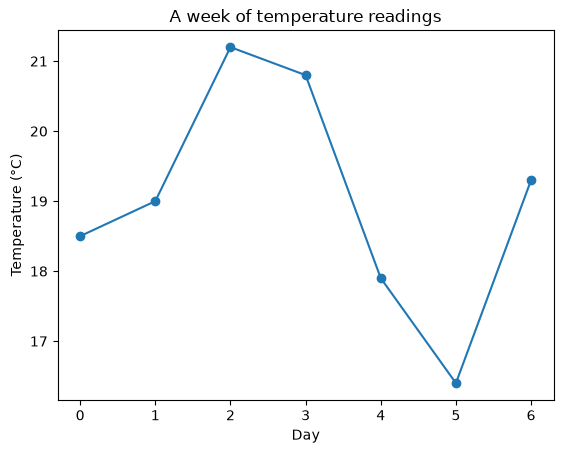

In [56]:
%matplotlib inline
import matplotlib.pyplot as plt

days = np.arange(7)

plt.plot(days, temperatures, marker="o")
plt.xlabel("Day")
plt.ylabel("Temperature (°C)")
plt.title("A week of temperature readings")
plt.show()

A bar chart — useful for comparing categories:

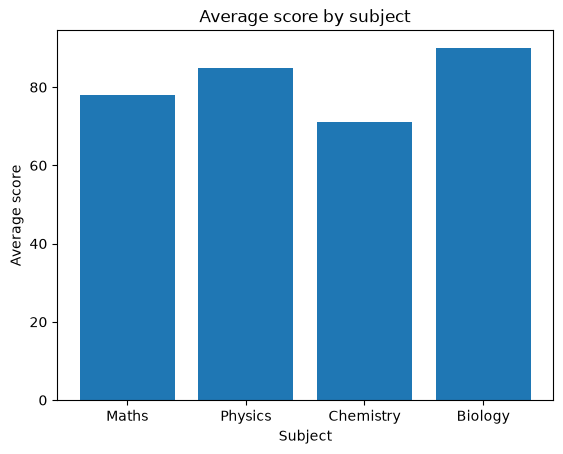

In [57]:
subjects = ["Maths", "Physics", "Chemistry", "Biology"]
average_scores = [78, 85, 71, 90]

plt.bar(subjects, average_scores)
plt.xlabel("Subject")
plt.ylabel("Average score")
plt.title("Average score by subject")
plt.show()

Multiple series and a legend — e.g. comparing the raw data to the fitted trend from section 6.2:

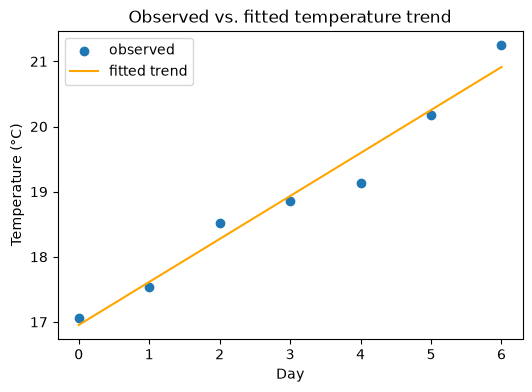

In [58]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(days, noisy_temps, label="observed")
ax.plot(days, linear_trend(days, slope, intercept), color="orange", label="fitted trend")
ax.set_xlabel("Day")
ax.set_ylabel("Temperature (°C)")
ax.set_title("Observed vs. fitted temperature trend")
ax.legend()
plt.show()

💡 (stretch) A scatter plot showing every point from a couple of arrays, with annotations:

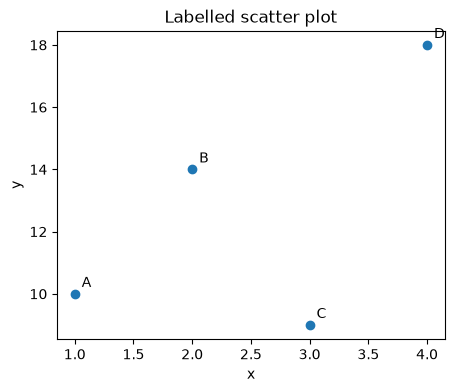

In [59]:
labels = ["A", "B", "C", "D"]
x_vals = np.array([1, 2, 3, 4])
y_vals = np.array([10, 14, 9, 18])

fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(x_vals, y_vals)
for label, x, y in zip(labels, x_vals, y_vals):
    ax.annotate(label, (x, y), textcoords="offset points", xytext=(5, 5))
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Labelled scatter plot")
plt.show()

**Exercise:** using the `heights` array from the NumPy exercise, make a bar chart with one bar per person, showing their height in centimetres. Label the axes and give the chart a title.

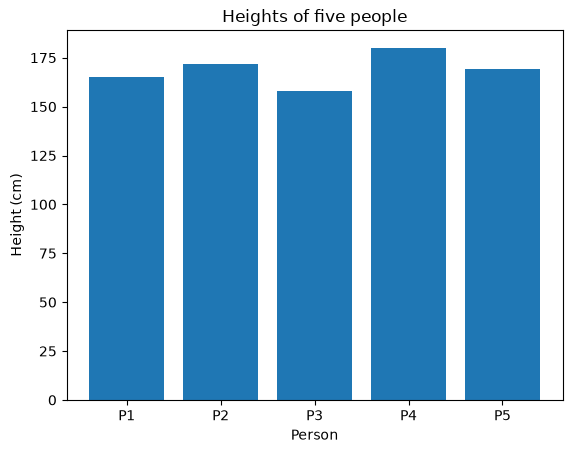

In [60]:
people = ["P1", "P2", "P3", "P4", "P5"]
heights_cm = heights * 100

plt.bar(people, heights_cm)
plt.xlabel("Person")
plt.ylabel("Height (cm)")
plt.title("Heights of five people")
plt.show()

---

## 7. Wrap-up

**What you now have:**

- Core Python syntax: variables, types, operators, `if`/`for`/`while`
- The four built-in data structures: `list`, `tuple`, `dict`, `set`
- Functions, and classes/objects — including composing objects out of other objects, and recognising that library objects (like `datetime.date` or `pathlib.Path`) work exactly the same way as the classes you wrote yourself
- How to manage packages and environments with Anaconda (`conda`) and `pip`
- NumPy arrays and linear algebra, a taste of SciPy, and Matplotlib plotting

**Common early pitfalls to watch for:**

- Indentation is *meaningful* in Python — a misaligned line under an `if`/`for`/`def` is a syntax error, not a style choice.
- `=` is assignment; `==` is comparison. `if x = 5` is a syntax error (which at least fails loudly).
- Indexing starts at `0`, not `1`.
- Running cells out of order can leave your notebook in a confusing state — if things look wrong, use the "Restart Kernel and Run All" option.
- `numpy` arrays vs. Python lists: `[1, 2] + [3, 4]` concatenates (`[1, 2, 3, 4]`), but `np.array([1, 2]) + np.array([3, 4])` adds element-wise (`[4, 6]`). Easy to trip over.

**Next up:** a dedicated session on quantum computing and Qiskit, building directly on the Python, NumPy and Matplotlib skills from today.

Questions? Ask now, or flag a TA during the break.